Celda 1: Importación de Librerías y Configuración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modelos Baselines y Tradicionales
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Métrica de evaluación solicitada
from sklearn.metrics import mean_absolute_error

# Intentar importar TabPFN (ajustar según tu instalación local de TabPFN v3)
try:
    from tabpfn import TabPFNRegressor
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False
    print("Nota: Asegúrate de tener instalado el paquete de tabpfn compatible con v3.")

import warnings
warnings.filterwarnings('ignore')

Celda 2: Carga de Datos y Exploración Inicial

In [2]:
# Cargar el dataset de vehículos
df = pd.read_csv('data_exam/cars.csv')

print(f"Dimensiones del dataset: {df.shape}")
print("\nPrimeras filas del conjunto de datos:")
display(df.head())

print("\nInformación general de tipos y nulos:")
df.info()

Dimensiones del dataset: (1703, 13)

Primeras filas del conjunto de datos:


,Price,Year,Kms,Miles,Fuel,Transmission,Owner,Seller,Drivetrain,Length,Width,Height,Seating
0,5656.0,2017,87150,54152.48265,Petrol,Manual,First,Corporate,FWD,3990,1680,1505,5
1,5040.0,2014,75000,46602.82500,Diesel,Manual,Second,Individual,FWD,3995,1695,1555,5
2,2464.0,2011,67000,41631.85700,Petrol,Manual,First,Individual,FWD,3585,1595,1550,5
3,8948.8,2019,37500,23301.41250,Petrol,Manual,First,Individual,FWD,3995,1745,1510,5
4,21840.0,2018,69000,42874.59900,Diesel,Manual,First,Individual,RWD,4735,1830,1795,7



Información general de tipos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703 entries, 0 to 1702
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         1703 non-null   float64
 1   Year          1703 non-null   int64  
 2   Kms           1703 non-null   int64  
 3   Miles         1703 non-null   float64
 4   Fuel          1703 non-null   object 
 5   Transmission  1703 non-null   object 
 6   Owner         1703 non-null   object 
 7   Seller        1701 non-null   object 
 8   Drivetrain    1703 non-null   object 
 9   Length        1703 non-null   int64  
 10  Width         1703 non-null   int64  
 11  Height        1703 non-null   int64  
 12  Seating       1703 non-null   int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 173.1+ KB


Celda 3: Feature Engineering (Ingeniería de Características)

In [3]:
# Duplicamos para no alterar el dataframe original directamente
df_fe = df.copy()

# 1. Eliminar redundancia: 'Miles' y 'Kms' miden lo mismo. Mantener 'Kms' y eliminar 'Miles'.
if 'Miles' in df_fe.columns:
    df_fe.drop(columns=['Miles'], inplace=True)

# 2. Creación de una nueva característica lógica: Kilómetros recorridos por año.
# Usamos un max con 1 para evitar divisiones por cero si el coche es del año actual (2026).
current_year = 2026
df_fe['Kms_per_Year'] = df_fe['Kms'] / (current_year - df_fe['Year']).clip(lower=1)

print("Columnas tras la ingeniería de características:")
print(df_fe.columns.tolist())

Columnas tras la ingeniería de características:
['Price', 'Year', 'Kms', 'Fuel', 'Transmission', 'Owner', 'Seller', 'Drivetrain', 'Length', 'Width', 'Height', 'Seating', 'Kms_per_Year']


Celda: Análisis de Valores Nulos (Data Preparation)

=== 1. Recuento Absoluto y Porcentual de Valores Nulos ===


,Valores Ausentes,Porcentaje (%)
Seller,2,0.11744



=== 2. Justificación Técnica de la Estrategia de Imputación ===


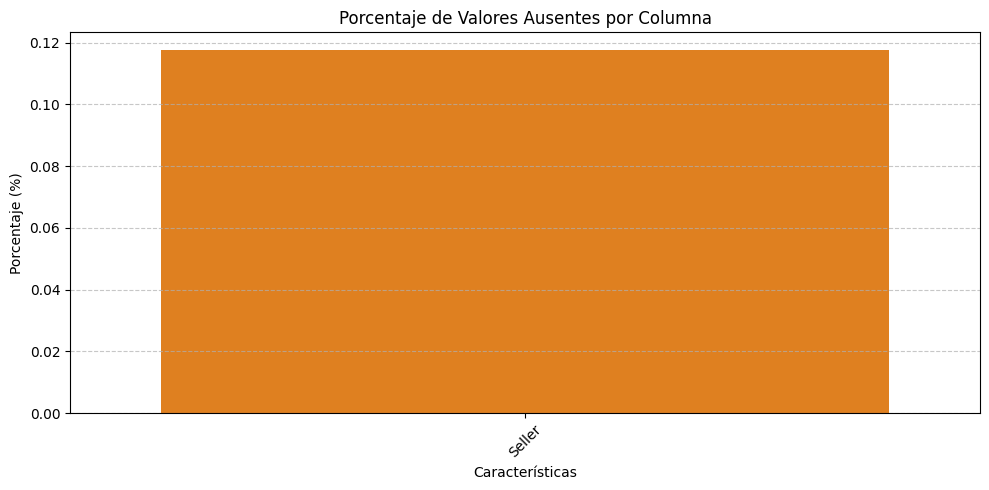

In [4]:
# APARTADO: Preparación de los datos - Estudio de Valores Nulos (Missing Values)

print("=== 1. Recuento Absoluto y Porcentual de Valores Nulos ===")
# Calcular la cantidad de nulos por columna
null_counts = df_fe.isnull().sum()
null_percentages = (df_fe.isnull().sum() / len(df_fe)) * 100

# Combinar en un único DataFrame para facilitar la lectura
df_missing = pd.DataFrame({
    'Valores Ausentes': null_counts,
    'Porcentaje (%)': null_percentages
}).sort_values(by='Valores Ausentes', ascending=False)

# Mostrar solo las columnas que tienen valores nulos
missing_cols = df_missing[df_missing['Valores Ausentes'] > 0]
if not missing_cols.empty:
    display(missing_cols)
else:
    print("No se han detectado valores nulos en ninguna columna del DataFrame.")

print("\n=== 2. Justificación Técnica de la Estrategia de Imputación ===")
# Inspeccionamos las variables con nulos (si las hay) para decidir la imputación:
# - Variables Numéricas: Si presentan asimetría o valores atípicos (outliers), 
#   la mediana ('median') es más robusta que la media.
# - Variables Categóricas: Se utiliza la moda o valor más frecuente ('most_frequent') 
#   para no alterar la distribución de categorías.

# Visualización opcional: Si hay nulos, generamos un gráfico de barras para el reporte
if not missing_cols.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_cols.index, y=missing_cols['Porcentaje (%)'], palette='autumn')
    plt.title('Porcentaje de Valores Ausentes por Columna')
    plt.ylabel('Porcentaje (%)')
    plt.xlabel('Características')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Al no haber nulos iniciales en este set, el Pipeline de preprocesamiento "
          "seguirá incluyendo 'SimpleImputer' como medida de seguridad activa "
          "para robustecer el modelo ante futuros datos en producción (fase de test o datos reales).")

Celda 4: Separación en Variables (X, y) y División Train/Test

In [5]:
# Definir variable objetivo y predictores
target = 'Price'
X = df_fe.drop(columns=[target])
y = df_fe[target]

# División en entrenamiento y prueba independiente (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Conjunto de Entrenamiento: {X_train.shape}")
print(f"Conjunto de Test: {X_test.shape}")

Conjunto de Entrenamiento: (1362, 12)
Conjunto de Test: (341, 12)


Celda 5: Configuración del Preprocesador (Pipeline & ColumnTransformer)

In [5]:
# Identificar tipos de columnas de forma automática
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Pipeline numérico: Imputación por mediana + Escalado estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline categórico: Imputación por el más frecuente + Codificación OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinar ambos flujos en el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Estructura del preprocesamiento lista.")

Estructura del preprocesamiento lista.


Celda 6: Inicialización del Diccionario de Resultados

In [6]:
# Estructura para almacenar las métricas de validación cruzada y test de cada modelo
results_summary = {}

def evaluate_pipeline_model(model_name, pipeline_obj, X_tr, y_tr, X_te, y_te):
    """Función auxiliar para entrenar, aplicar Cross-Validation y evaluar en Test"""
    # 1. Validación Cruzada (Métrica MAE)
    cv_results = cross_validate(pipeline_obj, X_tr, y_tr, cv=5, scoring='neg_mean_absolute_error')
    cv_mae_mean = -cv_results['test_score'].mean()
    cv_mae_std = cv_results['test_score'].std()
    
    # 2. Ajustar en todo el set de entrenamiento y evaluar en Test
    pipeline_obj.fit(X_tr, y_tr)
    preds_test = pipeline_obj.predict(X_te)
    test_mae = mean_absolute_error(y_te, preds_test)
    
    results_summary[model_name] = {
        'CV MAE Mean': cv_mae_mean,
        'CV MAE Std': cv_mae_std,
        'Test MAE': test_mae
    }
    print(f"[{model_name}] -> CV MAE: {cv_mae_mean:.2f} (±{cv_mae_std:.2f}) | Test MAE: {test_mae:.2f}")

Celda 7: Modelos Base (Dummy y Regresión Lineal)

In [7]:
# 1. Dummy Regressor (Línea base simple basada en la media)
dummy_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', DummyRegressor(strategy='mean'))])
evaluate_pipeline_model('Dummy (Mean)', dummy_pipe, X_train, y_train, X_test, y_test)

# 2. Regresión Lineal
lr_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())])
evaluate_pipeline_model('Linear Regression', lr_pipe, X_train, y_train, X_test, y_test)

[Dummy (Mean)] -> CV MAE: 8389.47 (±501.64) | Test MAE: 8717.77
[Linear Regression] -> CV MAE: 4085.30 (±334.86) | Test MAE: 4155.12


Celda 8: Modelos de Árboles por Defecto (Random Forest e HistGradientBoosting)

In [9]:
# 3. Random Forest con parámetros base
rf_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])
evaluate_pipeline_model('Random Forest (Base)', rf_base_pipe, X_train, y_train, X_test, y_test)

# 4. HistGradientBoosting (Maneja muy bien datos tabulares nativos)
hgb_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingRegressor(random_state=42))])
evaluate_pipeline_model('HistGradientBoosting (Base)', hgb_base_pipe, X_train, y_train, X_test, y_test)

[Random Forest (Base)] -> CV MAE: 1933.86 (±153.68) | Test MAE: 2106.14
[HistGradientBoosting (Base)] -> CV MAE: 1905.43 (±106.75) | Test MAE: 2072.52


Celda 9: Ajuste de Hiperparámetros (Tuning) para Random Forest

In [10]:
# Definición del espacio de búsqueda
param_dist_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}

rf_tune_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))])

search_rf = RandomizedSearchCV(rf_tune_pipe, param_distributions=param_dist_rf, 
                               n_iter=5, cv=5, scoring='neg_mean_absolute_error', 
                               random_state=42, n_jobs=-1)
search_rf.fit(X_train, y_train)

# Registrar rendimiento del mejor estimador encontrado
evaluate_pipeline_model('Random Forest (Tuned)', search_rf.best_estimator_, X_train, y_train, X_test, y_test)
print("Mejores parámetros RF:", search_rf.best_params_)

[Random Forest (Tuned)] -> CV MAE: 1934.02 (±155.03) | Test MAE: 2101.51
Mejores parámetros RF: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 20}


Celda 10: Ajuste de Hiperparámetros (Tuning) para HistGradientBoosting

In [11]:
param_dist_hgb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 10]
}

hgb_tune_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingRegressor(random_state=42))])

search_hgb = RandomizedSearchCV(hgb_tune_pipe, param_distributions=param_dist_hgb, 
                                n_iter=5, cv=5, scoring='neg_mean_absolute_error', 
                                random_state=42, n_jobs=-1)
search_hgb.fit(X_train, y_train)

evaluate_pipeline_model('HistGradientBoosting (Tuned)', search_hgb.best_estimator_, X_train, y_train, X_test, y_test)
print("Mejores parámetros HGB:", search_hgb.best_params_)

[HistGradientBoosting (Tuned)] -> CV MAE: 1913.52 (±101.87) | Test MAE: 2084.23
Mejores parámetros HGB: {'model__max_iter': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05}


Celda 11: Modelo Avanzado TabPFN v3

In [13]:
# Celda 11: Modelo Avanzado TabPFN v3
# Ruta física provista en tu entorno local para el modelo v3 de regresión
ckpt_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-regressor-v3_20260417_mediumdata.ckpt"

if TABPFN_AVAILABLE and os.path.exists(ckpt_path):
    # Añadimos 'ignore_pretraining_limits=True' para permitir ejecutar sets de datos grandes en CPU
    tabpfn_model = TabPFNRegressor(
        model_path=ckpt_path, 
        device='cpu',
        ignore_pretraining_limits=True
    )
    
    tabpfn_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', tabpfn_model)
    ])
    
    evaluate_pipeline_model('TabPFN v3', tabpfn_pipe, X_train, y_train, X_test, y_test)
else:
    print("Falta el paquete tabpfn o el archivo .ckpt no se encuentra en la ruta especificada.")

[TabPFN v3] -> CV MAE: 1478.00 (±136.85) | Test MAE: 1524.23


Celda 12: Tabla Comparativa de Resultados

=== TABLA COMPARATIVA DE RENDIMIENTO (Métrica principal: MAE) ===


,CV MAE Mean,CV MAE Std,Test MAE
TabPFN v3,1477.997958,136.846220,1524.233783
HistGradientBoosting (Base),1905.429926,106.752973,2072.519548
HistGradientBoosting (Tuned),1913.518961,101.869916,2084.230469
Random Forest (Tuned),1934.024528,155.031089,2101.508953
Random Forest (Base),1933.862326,153.680002,2106.140538
Linear Regression,4085.298515,334.862690,4155.119827
Dummy (Mean),8389.469023,501.641960,8717.765424


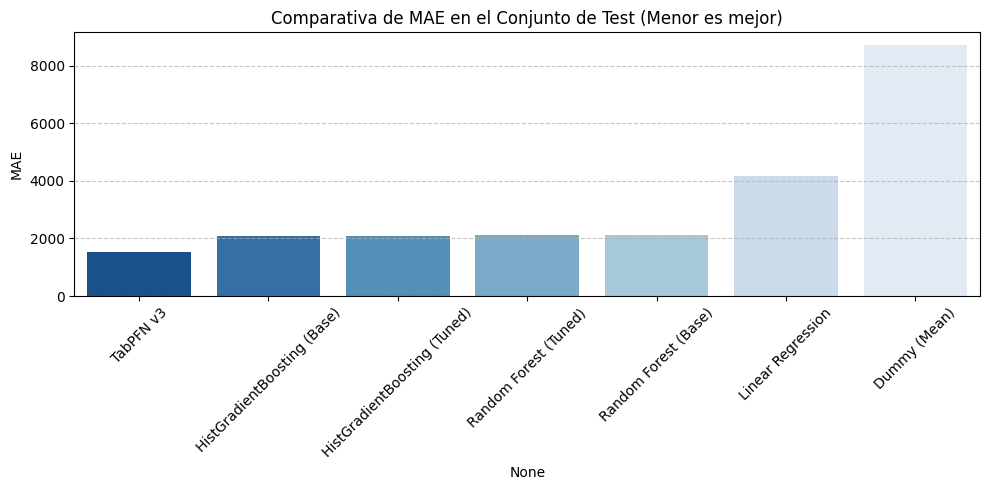

In [14]:
# Convertir el diccionario acumulado en un DataFrame ordenado de menor a mayor error en Test
df_results = pd.DataFrame(results_summary).T.sort_values(by='Test MAE')

print("=== TABLA COMPARATIVA DE RENDIMIENTO (Métrica principal: MAE) ===")
display(df_results)

# Gráfico de barras para visualizar la diferencia de errores
plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['Test MAE'], palette='Blues_r')
plt.title('Comparativa de MAE en el Conjunto de Test (Menor es mejor)')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Celda 13: Generación del Archivo de Predicciones Finales (CSV)

In [15]:
# Elegimos dinámicamente el modelo con el menor Test MAE registrado en el diccionario
best_model_name = df_results.index[0]
print(f"El modelo seleccionado para la producción es: {best_model_name}")

# En un caso real, reentrenamos la configuración ganadora con el 100% de los datos estructurados disponibles (X, y)
if best_model_name == 'HistGradientBoosting (Tuned)':
    final_model = search_hgb.best_estimator_
elif best_model_name == 'Random Forest (Tuned)':
    final_model = search_rf.best_estimator_
elif best_model_name == 'TabPFN v3':
    final_model = tabpfn_pipe
else:
    final_model = hgb_base_pipe

final_model.fit(X, y)

# Generación de predicciones finales sobre el set de prueba original
final_predictions = final_model.predict(X_test)

# Construcción del DataFrame resultante
output_predictions = pd.DataFrame({
    'Id_Vehiculo': X_test.index,
    'Precio_Original': y_test.values,
    'Precio_Predicho': final_predictions
})

# Exportación a formato CSV sin índices autonuméricos redundantes
output_csv_path = 'predictions_cars_final.csv'
output_predictions.to_csv(output_csv_path, index=False)

print(f"Archivo guardado con éxito en: '{output_csv_path}'")
display(output_predictions.head())

El modelo seleccionado para la producción es: TabPFN v3
Archivo guardado con éxito en: 'predictions_cars_final.csv'


,Id_Vehiculo,Precio_Original,Precio_Predicho
0,1046,11368.0000,10527.162109
1,745,33040.0000,35443.964844
2,785,5711.9888,5626.611328
3,367,10976.0000,11726.554688
4,1029,5040.0000,5763.409180
